In [16]:
import kwant
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig
from scipy.optimize import fmin
import os
from tqdm import tqdm
from joblib import Parallel, delayed
import matplotlib.patches as mpatches
from scipy.integrate import simpson  
from joblib import Parallel, delayed

In [83]:
#中间矩阵信息
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.array([[1, 0], [0, 1]], complex)

def h_k(m, B, a):
    return (m + 4*B/(a**2)) * sz

def h_x(B, a, A):
    return ((-B/(a**2))*sz - (1j/2)*A*sx) 
    
def h_y(B, a, A, Bz,xweizhi):
    return ((-B/(a**2))*sz - (1j/2)*A*sy) * np.exp(-(2*np.pi*1j*a**2)*Bz*xweizhi)

def h_onstie(m, B, a, u):
    return h_k(m, B, a) - u*s0

def t_x(B, a, A):
    return h_x(B, a, A)

def t_y(B, a, A, Bz, xweizhi):
    return h_y(B, a, A, Bz, xweizhi)


def H_onstie(m, B, a, u_set, xshumu, Nd, A):
    Z = np.zeros((Nd, Nd), dtype=complex)
    H = [[Z.copy() for _ in range(xshumu)] for _ in range(xshumu)]

    for i in range(xshumu):
        H[i][i] = h_onstie(m, B, a, u_set[i])

        if i < xshumu - 1:
            H[i][i+1] = t_x(B, a, A)

        if i > 0:
            H[i][i-1] = t_x(B, a, A).conj().T
    
    H = np.block(H)
    return H

def H_hop(B, a, A, xshumu, Nd,Bz):
    Z = np.zeros((Nd, Nd), dtype=complex)
    H = [[Z.copy() for _ in range(xshumu)] for _ in range(xshumu)]

    for i in range(xshumu):
        xweizhi=i
        H[i][i] = t_y(B, a, A, Bz,xweizhi)

    H = np.block(H)
    return H


m = -0.2       # 质量项
A = 1.0        # 费米速度项
B = 0.5        # 二阶动量项
Bz = 0.0  # 磁场
Ex = 0         # 电场相关

a = 1          # 晶格常数
yshumu = 50
xshumu = 10

uS = 0
uS_set = []
for i in range(xshumu):
    uS_set.append(uS - Ex * 1 * (i - xshumu/2))

uS_set_base = np.array(uS_set)

Nd = 2


H_q=H_onstie(m, B, a, uS_set_base, xshumu, Nd, A)

H_q_list = []
for i in range(yshumu):
    H_q_i = H_onstie(m, B, a, uS_set_base, xshumu, Nd, A)
    H_q_list.append(H_q_i)

T_21 = H_hop(B, a, A, xshumu, Nd,Bz)


if m * B < 0:
    leiN = 1  # Topological
else:
    leiN = 0  # Trivial




In [84]:
## 两边纳米线 
t = 10
tc = 0.2* t
mu = 20
weidu = 2
kuandu = 10  # 电极的横向宽度
Nd = 2        # 2x2 正常态
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.array([[1, 0], [0, 1]], complex)
def H_onsite_1(t,mu ,weidu):
    HX_block = -(mu - 2*weidu*t)*s0 
    return HX_block

def H_hop_1(t):
    # 纯粹的最近邻跳跃
    H_X_right_to_left_hop_block = -t * s0
    return H_X_right_to_left_hop_block

def H_onsite_2(t,mu, weidu, kuandu):
    Z = np.zeros((Nd, Nd), dtype=complex)
    H = [[Z.copy() for _ in range(kuandu)] for _ in range(kuandu)]

    for i in range(kuandu):
        H[i][i] = H_onsite_1(t,mu, weidu)


        if i < kuandu - 1:
            H[i][i+1] = H_hop_1(t)
        if i > 0:
            H[i][i-1] = H_hop_1(t).conj().T
    
    return np.block(H)

def H_hop_2(t, kuandu):
    Z = np.zeros((Nd, Nd), dtype=complex)
    H = [[Z.copy() for _ in range(kuandu)] for _ in range(kuandu)]

    for i in range(kuandu):

        H[i][i] = H_hop_1(t)

    return np.block(H)

# 矩阵信息

H_l = H_onsite_2(t,mu, weidu, kuandu)
T_l = H_hop_2(t, kuandu)

H_r = H_onsite_2(t,mu, weidu, kuandu)
T_r = H_hop_2(t, kuandu).conj().T


#整体耦合块
T_c = H_hop_2(tc, kuandu) 

# 左电极耦合矩阵
T_LD = np.zeros((Nd * kuandu, Nd * xshumu), dtype=complex)
T_LD[:, -Nd * kuandu:] = T_c.conj().T

# 右电极耦合矩阵
T_RD = np.zeros((Nd * kuandu, Nd * xshumu), dtype=complex)
T_RD[:, :Nd * kuandu] = T_c

print(f"2D 左电极 H_l 维度: {H_l.shape}")
print(f"左侧耦合矩阵 T_LD 维度: {T_LD.shape}")
#print(T_RD)

2D 左电极 H_l 维度: (20, 20)
左侧耦合矩阵 T_LD 维度: (20, 20)


In [19]:
#function
#T_l不可逆
def gr_L_keni(T_l, A_l, tol=1e-16):
    N = T_l.shape[0]
    I = np.eye(N)

    A = np.block([
        [np.zeros((N, N)), I],
        [-T_l.conj().T, A_l]
    ])

    B = np.block([
        [I, np.zeros((N, N))],
        [np.zeros((N, N)), T_l]
    ])

    eigvals, eigvecs = eig(A, B)

    lambdas = []
    modes = []

    for i, lam in enumerate(eigvals):
        if np.abs(lam) < 1 - tol:   # 衰减模式
            x = eigvecs[:N, i]
            x /= np.linalg.norm(x)
            lambdas.append(lam)
            modes.append(x)

    X = np.column_stack(modes)
    Lambda = np.diag(lambdas)
    #print(Lambda.shape,X.shape)
    F = X @ Lambda @ np.linalg.inv(X)

    gL = np.linalg.inv(A_l - T_l @ F)

    return gL

def gr_L(T_l, A_l, check_tol=1e-6):

    N = T_l.shape[0]
    I = np.eye(N)
    Tmat = np.block([
        [np.linalg.inv(T_l) @ A_l, -np.linalg.inv(T_l) @ T_l.conj().T],
        [I, np.zeros((N, N))]
    ])

    eigvals, eigvecs = eig(Tmat)


    idx = np.argsort(np.abs(eigvals))
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    lambdas = eigvals[:N]
    vecs = eigvecs[:, :N]

    S1 = vecs[:N, :] 
    S2 = vecs[N:, :]  

    gL = np.linalg.inv(A_l - T_l @ S1 @ np.linalg.inv(S2))
    #check = (A_l - T_l @ gL @ T_l.conj().T) @ gL - I
    #max_err = np.max(np.abs(check))

    return gL

def zinengr_L(T_LD_wei ,gr_L_wei):
    return T_LD_wei.conj().T @ gr_L_wei @ T_LD_wei

def Gr_DD(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, yshumu, E, Sigma_virtual_big, eta=1e-6):
    
    # 动态获取器件和电极的矩阵维度
    d_device = H_q_list[0].shape[0]  # 这里应该是单层的维度 (例如 4 * xshumu 或 2 * xshumu)
    d_lead = H_l.shape[0]            # 电极维度，例如 4 或 2
    
    I_device = np.eye(d_device, dtype=complex)
    Z = np.zeros((d_device, d_device), dtype=complex)

    # 注意：电极和中心区的维度不同，需要分别构建能量对角阵
    EI_lead = (E + 1j*eta) * np.eye(d_lead, dtype=complex)
    EI_device = (E + 1j*eta) * I_device

    # ---------------- 计算左电极自能 ----------------
    A_l = EI_lead - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    # ---------------- 计算右电极自能 ----------------
    A_r = EI_lead - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)

    # ------------- 构建总格林函数矩阵 A_DD -------------
    A_DD = [[Z.copy() for _ in range(yshumu)] for _ in range(yshumu)]

    for i in range(yshumu):
        # 从列表中取出对应 yweizhi (即 i) 的 H_q
        H_q_i = H_q_list[i]

        # 把真实引线的自能加在边界层
        if i == 0:
            A_DD[i][i] = EI_device - H_q_i - Sigma_L
        elif i == yshumu-1:
            A_DD[i][i] = EI_device - H_q_i - Sigma_R
        else:
            A_DD[i][i] = EI_device - H_q_i

        # 加上层间跃迁
        if i < yshumu-1:
            A_DD[i][i+1] = -T_21
        if i > 0:
            A_DD[i][i-1] = -T_21.conj().T
            
    # 将列表分块矩阵拼成一个完整的二维大矩阵
    A_DD = np.block(A_DD)
    
    # ==========================================
    # 核心修改：引入退相干效应
    # 减去全器件维度的虚拟探针自能大矩阵 Sigma_virtual_big
    # ==========================================
    A_DD = A_DD - Sigma_virtual_big
    
    # 对全矩阵求逆，得到包含退相干效应的总推迟格林函数
    G_DD_r = np.linalg.inv(A_DD)
    
    return G_DD_r, Sigma_R, Sigma_L

#新函数
def Gr_DD_2(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, yshumu, E, eta=1e-6):
    N = yshumu
    
    # 动态获取器件和电极的矩阵维度
    d_device = H_q_list[0].shape[0]  # 这里是 4 * xshumu = 160
    d_lead = H_l.shape[0]            # 电极维度，这里是 4
    
    I_device = np.eye(d_device, dtype=complex)
    
    # 构建能量对角阵
    EI_lead = (E + 1j*eta) * np.eye(d_lead, dtype=complex)
    EI_device = (E + 1j*eta) * I_device

    # ---------------- 计算左电极自能 ----------------
    A_l = EI_lead - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    # ---------------- 计算右电极自能 ----------------
    A_r = EI_lead - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)

    # ==========================================
    # 核心修改：使用 RGF 算法直接计算非对角块 G_RL
    # ==========================================
    V = T_21
    V_dagger = V.conj().T
    
    # gL 数组存储从左向右扫描的局域有效格林函数
    gL = np.zeros((N, d_device, d_device), dtype=complex)
    
    # 1. 第 0 层 (最左侧)：包含本层哈密顿量和左电极自能
    gL[0] = np.linalg.inv(EI_device - H_q_list[0] - Sigma_L)
    
    # 2. 中间层：通过 Dyson 方程，把左侧所有层的物理效应折叠为本层的等效自能
    for n in range(1, N-1):
        Sigma_eff_L = V_dagger @ gL[n-1] @ V
        gL[n] = np.linalg.inv(EI_device - H_q_list[n] - Sigma_eff_L)
        
    # 3. 第 N-1 层 (最右侧)：包含左侧传播来的等效自能，以及真实的右电极自能
    Sigma_eff_L_last = V_dagger @ gL[N-2] @ V
    gL[N-1] = np.linalg.inv(EI_device - H_q_list[N-1] - Sigma_eff_L_last - Sigma_R)
    
    # 4. 回溯提取透射矩阵 G_RL (即 G_{N-1, 0}，波函数从左侧 0 传播到右侧 N-1)
    G_RL = gL[N-1].copy()
    for n in range(N-2, -1, -1):
        G_RL = G_RL @ V_dagger @ gL[n]

    # 直接返回这三个计算电导的必需品，G_RL 的维度是 160x160
    return G_RL, Sigma_R, Sigma_L

def calculate_area_under_curve(x_data, y_data):
    """
    计算给定 x 和 y 离散数据点下方的面积
    """
    # 确保数据是 numpy 数组
    x_array = np.array(x_data)
    y_array = np.array(y_data)
    
    # 方法一：梯形积分法 (Trapezoidal rule)
    # 这是最基础、最稳妥的方法，通过把相邻点连成梯形来求面积
    area_trapz = np.trapz(y_array, x=x_array)
    
    # 方法二：辛普森积分法 (Simpson's rule)
    # 通过二次多项式拟合相邻的三个点，对于平滑的物理曲线（如电导平台）精度通常更高
    area_simps = simpson(y=y_array, x=x_array)
    
    return area_trapz, area_simps

def calc_T_eff(Bz_val, E_val):
    # 1. 动态更新层间跃迁矩阵
    T_21 = H_hop(B, a, A, xshumu, Nd, Bz_val)
    
    # 2. 计算格林函数 (传入全局组装好的不均匀 Sigma_virtual_big)
    G_all, Sigma_R, Sigma_L = Gr_DD(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, yshumu, E_val, Sigma_virtual_big, eta=1e-6)
    
    d_device = Sigma_L.shape[0] 
    
    # 3. 提取非零小矩阵块
    slices = []
    small_gammas = []
    
    # --- 左极 ---
    gamma_L_small = 1j * (Sigma_L - Sigma_L.conj().T)
    slices.append((0, d_device))
    small_gammas.append(gamma_L_small)
    
    # --- 虚拟探针 (核心修改：从 T_d_list 中按位置读取特定的展宽) ---
    for i in range(total_sites):
        slices.append((2 * i, 2 * i + 2))
        small_gammas.append(T_d_list[i])
        
    # --- 右极 ---
    gamma_R_small = 1j * (Sigma_R - Sigma_R.conj().T)
    slices.append((M - d_device, M))
    small_gammas.append(gamma_R_small)
    
    num_probes = len(slices)
    
    # 4. 极速计算透射矩阵 T_ij
    T_matrix = np.zeros((num_probes, num_probes), dtype=float)
    for i in range(num_probes):
        start_i, end_i = slices[i]
        gamma_i = small_gammas[i]
        for j in range(num_probes):
            if i == j: continue 
            start_j, end_j = slices[j]
            gamma_j = small_gammas[j]
            
            G_ij = G_all[start_i:end_i, start_j:end_j]
            Ga_ji = G_ij.conj().T
            T_matrix[i, j] = np.real(np.trace(gamma_i @ G_ij @ gamma_j @ Ga_ji))

    # 5. 解 Büttiker 虚拟电压方程
    V_L = 1.0
    V_R = 0.0
    W = np.zeros((total_sites, total_sites), dtype=float)
    B_vec = np.zeros(total_sites, dtype=float)
    
    for p in range(1, total_sites + 1):  
        row = p - 1  
        W[row, row] = np.sum(T_matrix[p, :])
        for q in range(1, total_sites + 1):
            if p != q:
                col = q - 1
                W[row, col] = -T_matrix[p, q]
        B_vec[row] = T_matrix[p, 0] * V_L + T_matrix[p, num_probes - 1] * V_R

    V_virtual = np.linalg.solve(W, B_vec)

    # 6. 整合有效电导 T_eff
    T_eff = T_matrix[0, num_probes - 1] * (V_L - V_R) 
    for v in range(1, total_sites + 1):
        T_eff += T_matrix[0, v] * (V_L - V_virtual[v - 1])
        
    return T_eff


In [94]:
#虚拟探针
total_sites = xshumu * yshumu
M = total_sites * 2  

# 设定基础的 T_d (目前作为统一初始值)
base_T_d = 0.05 * np.array([[1, 0], [0, 1]], dtype=complex)

# 核心修改：将每个格点的 T_d 和虚部自能存入列表，方便以后做成不一样的！
T_d_list = []
xushuzineng_list = []

for i in range(total_sites):
    # ---------------------------------------------------------
    # 未来你可以在这里写 if/else 逻辑！
    # 比如：前 xshumu 个 (即 i < xshumu) 是某种 T_d_edge
    # 其他的是 T_d_bulk 等等。
    # 现在我们先让它们统统等于 base_T_d
    # ---------------------------------------------------------
    current_T_d = base_T_d.copy()  
    
    T_d_list.append(current_T_d)
    xushuzineng_list.append(-1j * current_T_d / 2)


# 既然每个格点可能不一样了，就不能用 kron，改为手动分块组装大自能矩阵
Sigma_virtual_big = np.zeros((M, M), dtype=complex)
for i in range(total_sites):
    start_idx = 2 * i
    end_idx = 2 * i + 2
    Sigma_virtual_big[start_idx:end_idx, start_idx:end_idx] = xushuzineng_list[i]


Calculating Bands: 100%|██████████| 5001/5001 [00:00<00:00, 14359.05it/s]


1


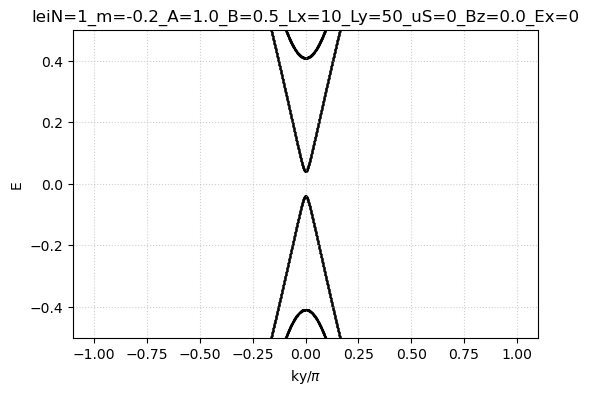

In [86]:
# 中间能带
params_str = f"leiN={leiN}_m={m}_A={A}_B={B}_Lx={xshumu}_Ly={yshumu}_uS={uS}_Bz={Bz}_Ex={Ex}"
ks1 = np.linspace(-1*np.pi, 1*np.pi,5001)
def Hk(k, H, T):
    # H(k) = H_onsite + T * exp(-ik) + T.conj().T * exp(ik)
    return H + T.conj().T * np.exp(-1j * k) + T * np.exp(1j * k)

energies1 = []

for k in tqdm(ks1, desc="Calculating Bands"):
    H_k = Hk(k, H_q, T_21)
    evals1 = np.linalg.eigvalsh(H_k)
    energies1.append(evals1)

energies1 = np.array(energies1)

plt.figure(figsize=(6, 4))

for i in range(energies1.shape[1]):
    plt.scatter(ks1/np.pi, energies1[:, i], color='black', s=0.1)
plt.ylim(-0.5,0.5)
#plt.xlim(-0.002,0.002)
#plt.ylim(-0.001,0.001)
#plt.xlim(-0.5,0.5)
plt.xlabel(r'ky/$\pi$')
plt.ylabel('E')
plt.title(f'{params_str}')
plt.grid(True, linestyle=':', alpha=0.6)
#save_fig_by_title_1(params_str)
print(leiN)
plt.show()

Calculating Non-Hermitian Bands: 100%|██████████| 5001/5001 [00:00<00:00, 12557.64it/s]


Topological invariant (leiN): 1


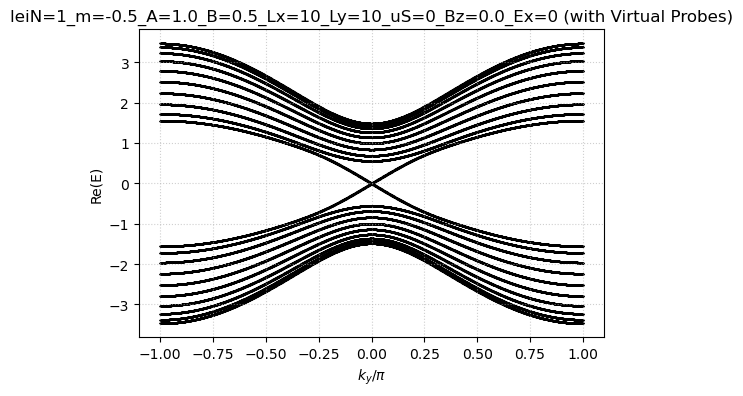

In [56]:
#能带
Sigma_slice = np.zeros((xshumu * Nd, xshumu * Nd), dtype=complex)

for i in range(xshumu):
    start_idx = Nd * i
    end_idx = Nd * i + Nd
    # 这里我们给所有格点加上相同的虚部自能
    # 你后续可以在这里写 if/else 给边缘和体态加不同的探针强度
    current_T_d = base_T_d.copy() 
    Sigma_slice[start_idx:end_idx, start_idx:end_idx] = -1j * current_T_d / 2

# 2. 将自能加入单胞哈密顿量，得到非厄米有效哈密顿量
H_q_eff = H_q + Sigma_slice

# 中间能带计算
params_str = f"leiN={leiN}_m={m}_A={A}_B={B}_Lx={xshumu}_Ly={yshumu}_uS={uS}_Bz={Bz}_Ex={Ex}"
ks1 = np.linspace(-1*np.pi, 1*np.pi, 5001)

def Hk(k, H, T):
    # H(k) = H_onsite + T * exp(-ik) + T.conj().T * exp(ik)
    return H + T.conj().T * np.exp(-1j * k) + T * np.exp(1j * k)

energies1 = []

for k in tqdm(ks1, desc="Calculating Non-Hermitian Bands"):
    # 传入带有自能的 H_q_eff
    H_k = Hk(k, H_q_eff, T_21)
    
    # 【关键修改】：改用 eigvals 计算非厄米矩阵的复数本征值
    evals1 = np.linalg.eigvals(H_k)
    
    # 为了绘图连贯，通常按照本征值的【实部】进行排序
    evals1 = evals1[np.argsort(evals1.real)]
    energies1.append(evals1)

energies1 = np.array(energies1)

# 3. 绘图
plt.figure(figsize=(6, 4))

for i in range(energies1.shape[1]):
    plt.scatter(ks1/np.pi, energies1[:, i].real, color='black', s=0.1)

# 建议稍微放宽一点视野，否则太小了看不到完整的线
#plt.xlim(-0.002, 0.002)
#plt.ylim(-0.001, 0.001)
#plt.xlim(-0.1, 0.1) 
#plt.ylim(-0.5, 0.5) 

plt.xlabel(r'$k_y/\pi$')
plt.ylabel('Re(E)') # 纵坐标现在是能量的实部
plt.title(f'{params_str} (with Virtual Probes)')
plt.grid(True, linestyle=':', alpha=0.6)
print("Topological invariant (leiN):", leiN)
plt.show()

Calculating Bands:   0%|          | 0/5001 [00:00<?, ?it/s]

Calculating Bands: 100%|██████████| 5001/5001 [00:00<00:00, 17469.78it/s]


1


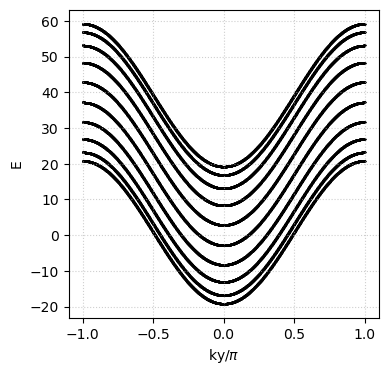

In [69]:
# 两边能带
#params_str = f"leiN={leiN}_m={m}_A={A}_B={B}_Lx={xshumu}_Ly={yshumu}_uS={uS}_Bz={Bz}_Ex={Ex}"
ks1 = np.linspace(-1*np.pi, 1*np.pi,5001)
def Hk(k, H, T):
    # H(k) = H_onsite + T * exp(-ik) + T.conj().T * exp(ik)
    return H + T.conj().T * np.exp(-1j * k) + T * np.exp(1j * k)

energies1 = []

for k in tqdm(ks1, desc="Calculating Bands"):
    H_k = Hk(k, H_l, T_l)
    evals1 = np.linalg.eigvalsh(H_k)
    energies1.append(evals1)

energies1 = np.array(energies1)

plt.figure(figsize=(4, 4))

for i in range(energies1.shape[1]):
    plt.scatter(ks1/np.pi, energies1[:, i], color='black', s=0.1)
#plt.ylim(-0.25,0.25)
#plt.xlim(-0.002,0.002)
#plt.ylim(-0.1,0.3)
#plt.xlim(-0.5,0.5)
plt.xlabel(r'ky/$\pi$')
plt.ylabel('E')
#plt.title(f'{params_str}')
plt.grid(True, linestyle=':', alpha=0.6)
#save_fig_by_title_1(params_str)
print(leiN)
plt.show()

Calculating Bands: 100%|██████████| 5001/5001 [00:00<00:00, 17364.88it/s]


1


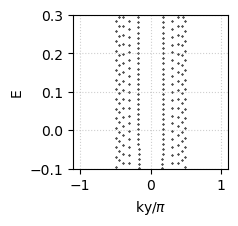

In [70]:
# 两边能带
#params_str = f"leiN={leiN}_m={m}_A={A}_B={B}_Lx={xshumu}_Ly={yshumu}_uS={uS}_Bz={Bz}_Ex={Ex}"
ks1 = np.linspace(-1*np.pi, 1*np.pi,5001)
def Hk(k, H, T):
    # H(k) = H_onsite + T * exp(-ik) + T.conj().T * exp(ik)
    return H + T.conj().T * np.exp(-1j * k) + T * np.exp(1j * k)

energies1 = []

for k in tqdm(ks1, desc="Calculating Bands"):
    H_k = Hk(k, H_r, T_r)
    evals1 = np.linalg.eigvalsh(H_k)
    energies1.append(evals1)

energies1 = np.array(energies1)

plt.figure(figsize=(2, 2))

for i in range(energies1.shape[1]):
    plt.scatter(ks1/np.pi, energies1[:, i], color='black', s=0.1)
#plt.ylim(-0.25,0.25)
#plt.xlim(-0.002,0.002)
plt.ylim(-0.1,0.3)
#plt.xlim(-0.5,0.5)
plt.xlabel(r'ky/$\pi$')
plt.ylabel('E')
#plt.title(f'{params_str}')
plt.grid(True, linestyle=':', alpha=0.6)
#save_fig_by_title_1(params_str)
print(leiN)
plt.show()

开始扫描磁场 Bz，共 500 个点 (启动 14 进程并行计算)...


Calculating T_eff (Parallel): 100%|██████████| 500/500 [00:05<00:00, 96.15it/s] 


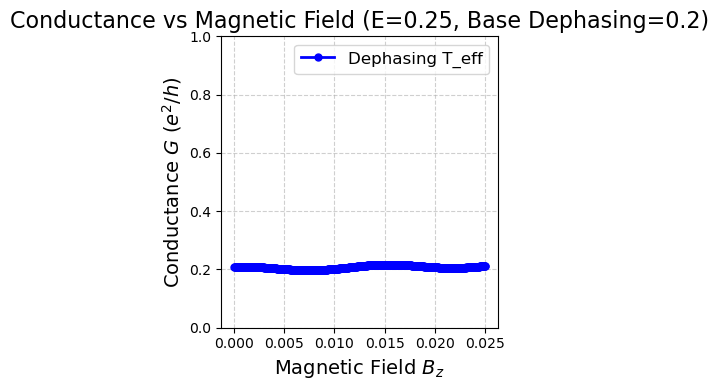


电导曲线下方面积 (梯形积分): 0.005183


In [24]:
#G vs Bz G_DD
# ==========================================
# 3. 多核并行扫描磁场并绘制曲线
# ==========================================
E=0.25
num_points = 500
Bz_values = np.linspace(0, 0.025, num_points)

print(f"开始扫描磁场 Bz，共 {num_points} 个点 (启动 14 进程并行计算)...")

# 核心修改：使用 joblib 的 Parallel 和 delayed 实现多进程并行计算
T_eff_results = Parallel(n_jobs=14)(
    delayed(calc_T_eff)(Bz_val, E) for Bz_val in tqdm(Bz_values, desc="Calculating T_eff (Parallel)")
)

# 将列表转化为 numpy 数组
T_eff_results = np.array(T_eff_results)

# 绘制最终的物理图像
plt.figure(figsize=(4, 4))
plt.plot(Bz_values, T_eff_results, 'bo-', linewidth=2, markersize=5, label='Dephasing T_eff')
plt.xlabel(r'Magnetic Field $B_z$', fontsize=14)
plt.ylabel(r'Conductance $G \ (e^2/h)$', fontsize=14)
# 画图标题提取 base_T_d 以防之后列表里各不相同
plt.title(f'Conductance vs Magnetic Field (E={E}, Base Dephasing={base_T_d[0,0].real})', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()
plt.ylim(0, 1) # 根据你的实际物理需求调节
plt.show()

# ==========================================
# 4. 计算面积 (积分)
# ==========================================
# 计算 Bz_values 和 T_eff_results 包围的面积
area_trapz = np.trapz(T_eff_results, x=Bz_values)
print(f"\n电导曲线下方面积 (梯形积分): {area_trapz:.6f}")

开始扫描能量 E，共 500 个点 (启动 14 进程并行计算)...


Calculating T_eff (Parallel): 100%|██████████| 500/500 [10:32<00:00,  1.27s/it]


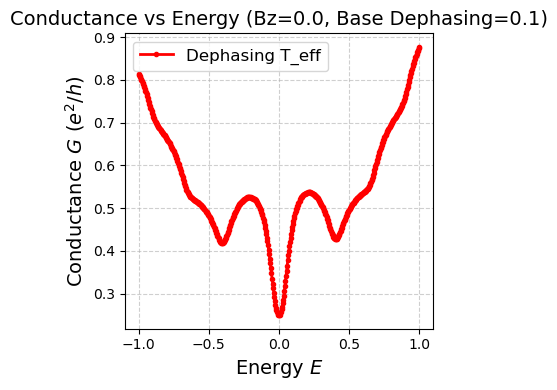


电导曲线下方面积 (梯形积分): 1.100947


In [89]:
#G vs E G_DD
# 设定固定的磁场 Bz
Bz_fixed = 0.0  # 根据你的物理需求修改这个固定的磁场值

# 设定扫描的能量点
num_points = 500
# 这里的能量范围 (比如 0.0 到 0.5) 请根据你的能带结构和关注的区间进行调整
#E_values = np.linspace(-0.001, 0.001, num_points)
E_values = np.linspace(-1, 1, num_points)

print(f"开始扫描能量 E，共 {num_points} 个点 (启动 14 进程并行计算)...")

# 核心修改：固定 Bz_fixed，遍历 E_values 进行多进程计算
T_eff_results = Parallel(n_jobs=14)(
    delayed(calc_T_eff)(Bz_fixed, E_val) for E_val in tqdm(E_values, desc="Calculating T_eff (Parallel)")
)

# 将列表转化为 numpy 数组
T_eff_results = np.array(T_eff_results)

# 绘制最终的物理图像
plt.figure(figsize=(4, 4)) # 稍微调宽了一点让能量轴更好看
plt.plot(E_values, T_eff_results, 'ro-', linewidth=2, markersize=3, label='Dephasing T_eff')
plt.xlabel(r'Energy $E$', fontsize=14)
plt.ylabel(r'Conductance $G \ (e^2/h)$', fontsize=14)

# 画图标题提取 base_T_d 和固定的 Bz_fixed
plt.title(f'Conductance vs Energy (Bz={Bz_fixed}, Base Dephasing={base_T_d[0,0].real})', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()
# 纵坐标范围可以根据实际有无大于1的台阶进行调节，比如如果是多通道可能需要 plt.ylim(0, 2) 或更高
#plt.ylim(0, 1.1) 
plt.show()

# ==========================================
# 4. 计算面积 (积分)
# ==========================================
# 计算 E_values 和 T_eff_results 包围的面积
area_trapz = np.trapz(T_eff_results, x=E_values)
print(f"\n电导曲线下方面积 (梯形积分): {area_trapz:.6f}")

开始扫描能量 E，共 100 个点 (启动 14 进程并行计算)...


Calculating T_eff (Parallel): 100%|██████████| 100/100 [00:31<00:00,  3.22it/s]


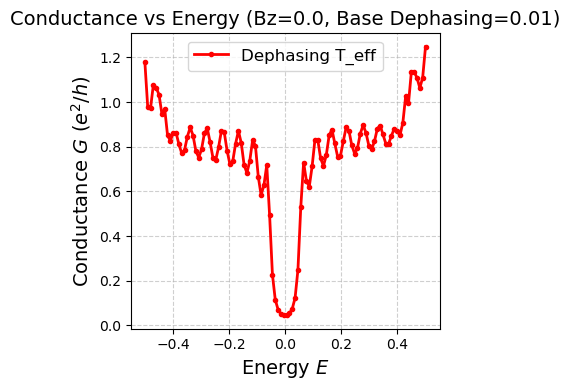


电导曲线下方面积 (梯形积分): 0.762942


In [92]:
#G vs E G_DD
# 设定固定的磁场 Bz
Bz_fixed = 0.0  # 根据你的物理需求修改这个固定的磁场值

# 设定扫描的能量点
num_points = 100
# 这里的能量范围 (比如 0.0 到 0.5) 请根据你的能带结构和关注的区间进行调整
#E_values = np.linspace(-0.001, 0.001, num_points)
E_values = np.linspace(-0.5, 0.5, num_points)

print(f"开始扫描能量 E，共 {num_points} 个点 (启动 14 进程并行计算)...")

# 核心修改：固定 Bz_fixed，遍历 E_values 进行多进程计算
T_eff_results = Parallel(n_jobs=14)(
    delayed(calc_T_eff)(Bz_fixed, E_val) for E_val in tqdm(E_values, desc="Calculating T_eff (Parallel)")
)

# 将列表转化为 numpy 数组
T_eff_results = np.array(T_eff_results)

# 绘制最终的物理图像
plt.figure(figsize=(4, 4)) # 稍微调宽了一点让能量轴更好看
plt.plot(E_values, T_eff_results, 'ro-', linewidth=2, markersize=3, label='Dephasing T_eff')
plt.xlabel(r'Energy $E$', fontsize=14)
plt.ylabel(r'Conductance $G \ (e^2/h)$', fontsize=14)

# 画图标题提取 base_T_d 和固定的 Bz_fixed
plt.title(f'Conductance vs Energy (Bz={Bz_fixed}, Base Dephasing={base_T_d[0,0].real})', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()
# 纵坐标范围可以根据实际有无大于1的台阶进行调节，比如如果是多通道可能需要 plt.ylim(0, 2) 或更高
#plt.ylim(0, 1.1) 
plt.show()

# ==========================================
# 4. 计算面积 (积分)
# ==========================================
# 计算 E_values 和 T_eff_results 包围的面积
area_trapz = np.trapz(T_eff_results, x=E_values)
print(f"\n电导曲线下方面积 (梯形积分): {area_trapz:.6f}")

开始扫描能量 E，共 100 个点 (启动 14 进程并行计算)...


Calculating T_eff (Parallel): 100%|██████████| 100/100 [00:31<00:00,  3.16it/s]


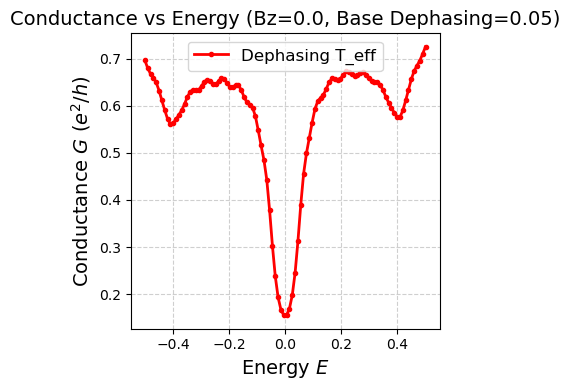


电导曲线下方面积 (梯形积分): 0.577276


In [95]:
#G vs E G_DD
# 设定固定的磁场 Bz
Bz_fixed = 0.0  # 根据你的物理需求修改这个固定的磁场值

# 设定扫描的能量点
num_points = 100
# 这里的能量范围 (比如 0.0 到 0.5) 请根据你的能带结构和关注的区间进行调整
#E_values = np.linspace(-0.001, 0.001, num_points)
E_values = np.linspace(-0.5, 0.5, num_points)

print(f"开始扫描能量 E，共 {num_points} 个点 (启动 14 进程并行计算)...")

# 核心修改：固定 Bz_fixed，遍历 E_values 进行多进程计算
T_eff_results = Parallel(n_jobs=14)(
    delayed(calc_T_eff)(Bz_fixed, E_val) for E_val in tqdm(E_values, desc="Calculating T_eff (Parallel)")
)

# 将列表转化为 numpy 数组
T_eff_results = np.array(T_eff_results)

# 绘制最终的物理图像
plt.figure(figsize=(4, 4)) # 稍微调宽了一点让能量轴更好看
plt.plot(E_values, T_eff_results, 'ro-', linewidth=2, markersize=3, label='Dephasing T_eff')
plt.xlabel(r'Energy $E$', fontsize=14)
plt.ylabel(r'Conductance $G \ (e^2/h)$', fontsize=14)

# 画图标题提取 base_T_d 和固定的 Bz_fixed
plt.title(f'Conductance vs Energy (Bz={Bz_fixed}, Base Dephasing={base_T_d[0,0].real})', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()
# 纵坐标范围可以根据实际有无大于1的台阶进行调节，比如如果是多通道可能需要 plt.ylim(0, 2) 或更高
#plt.ylim(0, 1.1) 
plt.show()

# ==========================================
# 4. 计算面积 (积分)
# ==========================================
# 计算 E_values 和 T_eff_results 包围的面积
area_trapz = np.trapz(T_eff_results, x=E_values)
print(f"\n电导曲线下方面积 (梯形积分): {area_trapz:.6f}")

固定 Bz = 0.0, 开始使用 RGF 算法扫描能量 E 并计算电导 (启动 14 进程并行计算)...


Scanning E (Parallel): 100%|██████████| 3000/3000 [00:06<00:00, 453.28it/s]


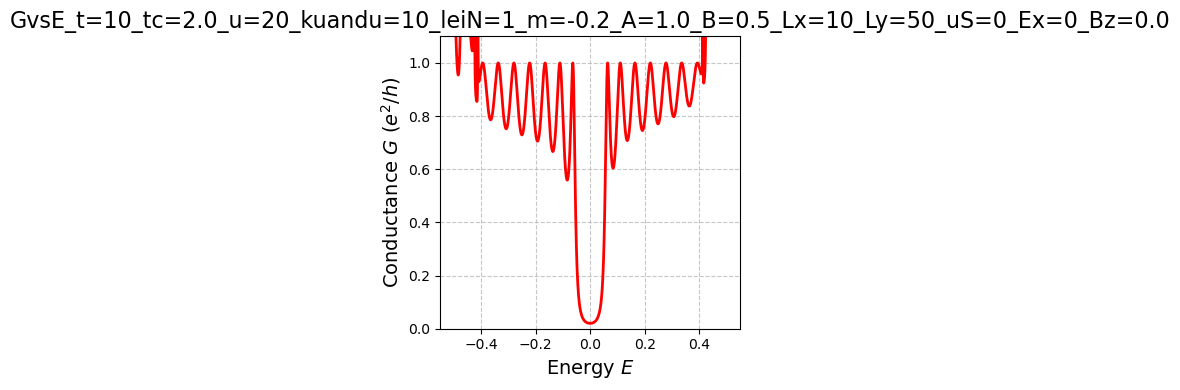


电导曲线下方面积 (梯形积分): 0.835762


In [87]:
# G vs E     G_DD_2
Bz = 0.0  # 将原先固定的 E 换成固定的 Bz
E0 = -0.025
E1 = 0.025  # 能量扫描范围，你可以根据需要调整
dianshu = 3000
#E_values = np.linspace(-0.001, -0.001, dianshu)
E_values = np.linspace(-0.5, 0.5, dianshu)
eta = 1e-6

# 定义保存路径 (这里稍微改了下 params_str_1 的后缀，把固定的 E 换成 Bz)
save_dir = rf"D:\结果\2026.4.27"
params_str_1 = f"t={t}_tc={tc}_u={mu}_kuandu={kuandu}_leiN={leiN}_m={m}_A={A}_B={B}_Lx={xshumu}_Ly={yshumu}_uS={uS}_Ex={Ex}_Bz={Bz}"

print(f"固定 Bz = {Bz}, 开始使用 RGF 算法扫描能量 E 并计算电导 (启动 14 进程并行计算)...")

# ==========================================
# 核心修改：将输入参数从 Bz_1 换成 E_val
# ==========================================
def calc_single_E_2(E_val):
    H_q_list = []
    for i in range(yshumu):
        H_q_i = H_onstie(m, B, a, uS_set_base, xshumu, Nd, A)
        H_q_list.append(H_q_i)
    # T_21 现在使用外面固定的 Bz
    T_21 = H_hop(B, a, A, xshumu, Nd, Bz)

    # ⚠️ 如果正式算磁场，记得这里要更新右电极！(遵照你的要求，这里保持注释状态不动)
    # H_r = H_onstie(m, B, a, uS_set_base, xshumu, Nd, A, Bz, yshumu)

    # 将 E_val 传给 Gr_DD_2
    G_RL, Sigma_R, Sigma_L = Gr_DD_2(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, yshumu, E_val, eta=eta)

    zhankuanL = 1j * (Sigma_L - Sigma_L.conj().T)
    zhankuanR = 1j * (Sigma_R - Sigma_R.conj().T)

    G_complex = np.trace(zhankuanR @ G_RL @ zhankuanL @ G_RL.conj().T)
    G_real = np.real(G_complex)
    
    return G_real

# 开启多核并行扫描 E_values
G_values = Parallel(n_jobs=14)(
    delayed(calc_single_E_2)(E_val) for E_val in tqdm(E_values, desc="Scanning E (Parallel)")
)

# ----------------- 画图部分 -----------------
plt.figure(figsize=(4, 4)) 
# 把 x 轴变量换成 E_values，颜色我换成了红色 ('r') 以示区别
plt.plot(E_values, G_values, linestyle='-', color='r', linewidth=2)

plt.xlabel(r'Energy $E$', fontsize=14)
plt.ylabel(r'Conductance $G \ (e^2/h)$', fontsize=14)
plt.title(fr'GvsE_{params_str_1}', fontsize=16)

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# 显示图像 (如果台阶大于 1 可以把这里上限调大)
plt.ylim(0, 1.1)
plt.show()

# 积分的 x 轴也换成 E_values
area_trapz = np.trapz(G_values, x=E_values)
print(f"\n电导曲线下方面积 (梯形积分): {area_trapz:.6f}")

固定 E = 0.25, 开始使用 RGF 算法扫描磁场 Bz 并计算电导 (启动 14 进程并行计算)...


Scanning Bz (Parallel): 100%|██████████| 2501/2501 [00:01<00:00, 1646.46it/s]


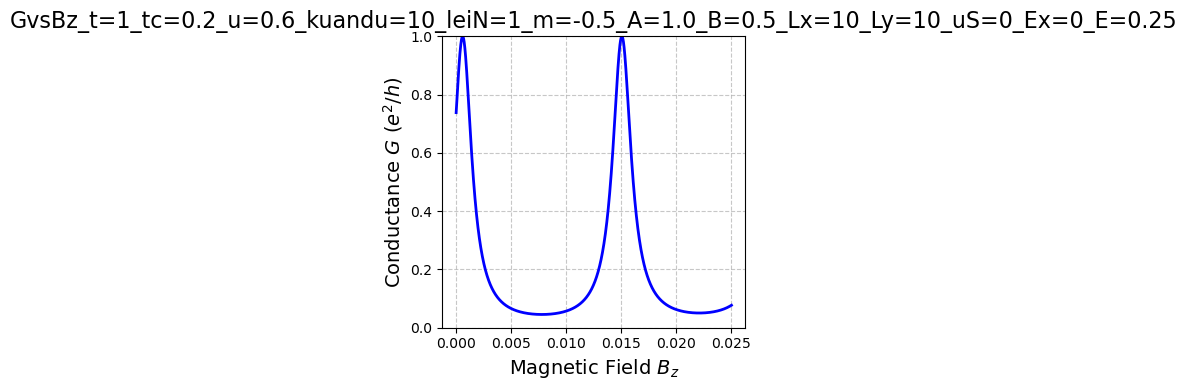


电导曲线下方面积 (梯形积分): 0.005355


In [27]:
# 设定固定的 E 和要扫描的 Bz 范围 多核心计算
E = 0.25
Bz0 = 0
Bz1 = 0.025
dianshu = 2501
Bz_values = np.linspace(Bz0, Bz1, dianshu)
eta = 1e-6
# 定义保存路径
save_dir = rf"D:\结果\2026.4.27"
params_str_1 = f"t={t}_tc={tc}_u={mu}_kuandu={kuandu}_leiN={leiN}_m={m}_A={A}_B={B}_Lx={xshumu}_Ly={yshumu}_uS={uS}_Ex={Ex}_E={E}"


print(f"固定 E = {E}, 开始使用 RGF 算法扫描磁场 Bz 并计算电导 (启动 14 进程并行计算)...")

# ==========================================
# 核心修改：将循环内的计算逻辑打包成一个独立函数
# ==========================================
def calc_single_Bz_2(Bz_1):
    H_q_list = []
    for i in range(yshumu):
        H_q_i = H_onstie(m, B, a, uS_set_base, xshumu, Nd, A)
        H_q_list.append(H_q_i)
    T_21 = H_hop(B, a, A, xshumu, Nd, Bz_1)

    # ⚠️ 如果正式算磁场，记得这里要更新右电极！(遵照你的要求，这里保持注释状态不动)
    # H_r = H_onstie(m, B, a, uS_set_base, xshumu, Nd, A, Bz_1, yshumu)

    G_RL, Sigma_R, Sigma_L = Gr_DD_2(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, yshumu, E, eta=eta)

    zhankuanL = 1j * (Sigma_L - Sigma_L.conj().T)
    zhankuanR = 1j * (Sigma_R - Sigma_R.conj().T)

    G_complex = np.trace(zhankuanR @ G_RL @ zhankuanL @ G_RL.conj().T)
    G_real = np.real(G_complex)
    
    return G_real

G_values = Parallel(n_jobs=14)(
    delayed(calc_single_Bz_2)(Bz_1) for Bz_1 in tqdm(Bz_values, desc="Scanning Bz (Parallel)")
)

# ----------------- 画图部分 -----------------
plt.figure(figsize=(4, 4)) 
plt.plot(Bz_values, G_values, linestyle='-', color='b', linewidth=2)

plt.xlabel(r'Magnetic Field $B_z$', fontsize=14)
plt.ylabel(r'Conductance $G \ (e^2/h)$', fontsize=14)
plt.title(fr'GvsBz_{params_str_1}', fontsize=16)

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()


# 显示图像
plt.ylim(0,1)
plt.show()

area_trapz = np.trapz(G_values, x=Bz_values)
print(f"\n电导曲线下方面积 (梯形积分): {area_trapz:.6f}")